In [36]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(r"C:\Users\Sahil more\Downloads\IT_motives_2013.csv")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df_clean = df[~df['State/UTs'].str.contains('Total', na=False)].copy()
df_clean = df_clean.drop(columns=["Crime Head", "Year"])

Shape: (38, 12)


In [37]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   State/UTs                               38 non-null     object
 1   Crime Head                              38 non-null     object
 2   Year                                    38 non-null     int64 
 3   Revenge /Settling scores                38 non-null     int64 
 4   Greed/ Money                            38 non-null     int64 
 5   Extortion                               38 non-null     int64 
 6   Cause Disrepute                         38 non-null     int64 
 7   Prank/ Satisfaction of Gaining Control  38 non-null     int64 
 8   Fraud/ Illegal Gain                     38 non-null     int64 
 9   Eve teasing/ Harassment                 38 non-null     int64 
 10  Others                                  38 non-null     int64 
 11  Total   

,Year,Revenge /Settling scores,Greed/ Money,Extortion,Cause Disrepute,Prank/ Satisfaction of Gaining Control,Fraud/ Illegal Gain,Eve teasing/ Harassment,Others,Total
count,38.0,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,2013.0,8.842105,64.815789,5.763158,11.684211,3.078947,97.894737,88.105263,169.263158,449.447368
std,0.0,24.694377,182.817418,16.915424,33.741550,8.999644,280.507917,249.644589,466.243567,1249.960966
min,2013.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2013.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,11.750000
50%,2013.0,0.000000,4.500000,0.000000,0.000000,0.000000,4.000000,7.500000,26.500000,83.500000
75%,2013.0,5.000000,40.000000,1.500000,5.250000,0.000000,30.750000,33.250000,123.750000,316.500000
max,2013.0,112.000000,821.000000,73.000000,148.000000,39.000000,1240.000000,1116.000000,2144.000000,5693.000000


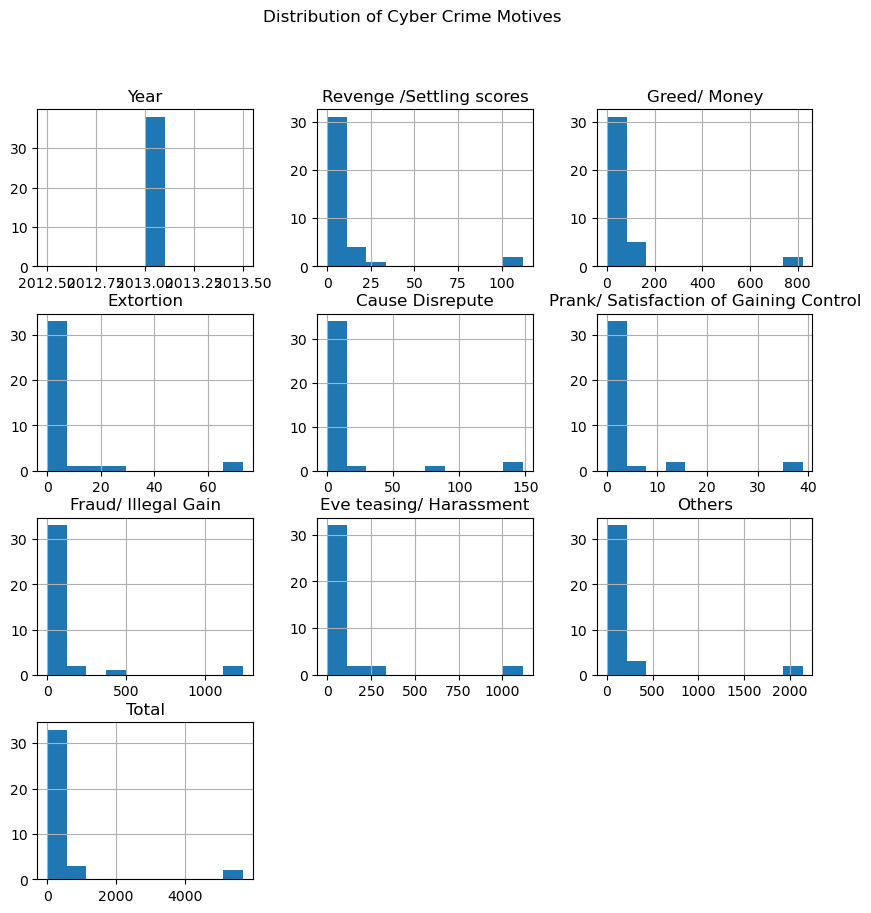

In [38]:


# Histogram
df.hist(figsize=(10,10))
plt.suptitle("Distribution of Cyber Crime Motives")
plt.show()



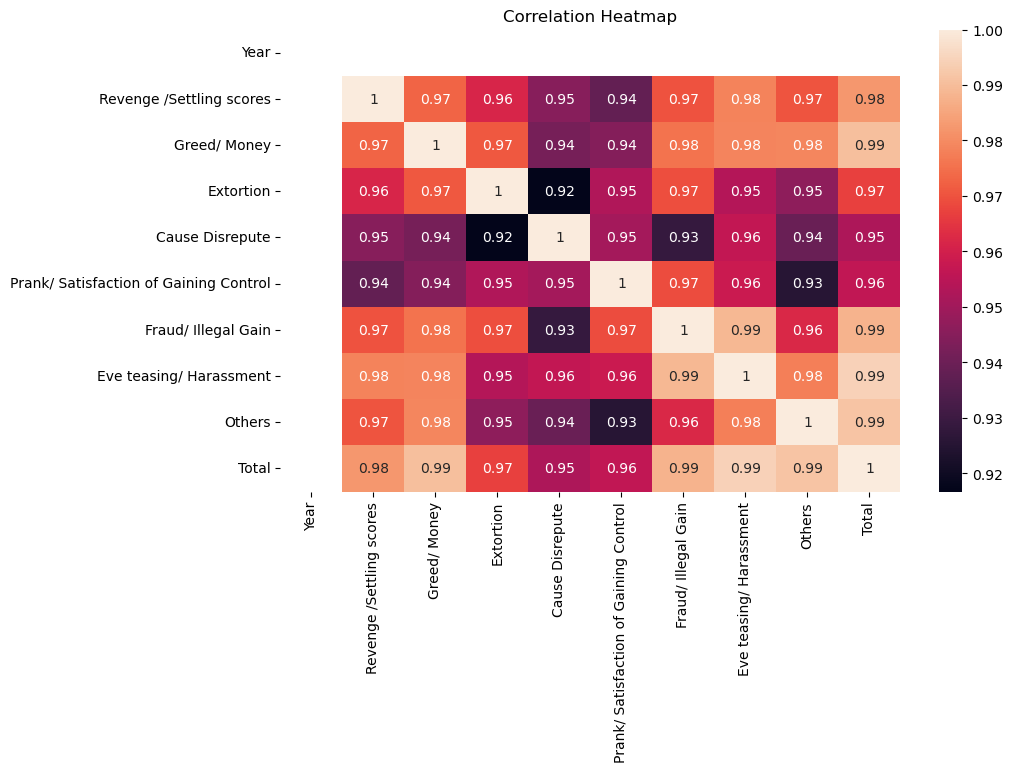

In [39]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

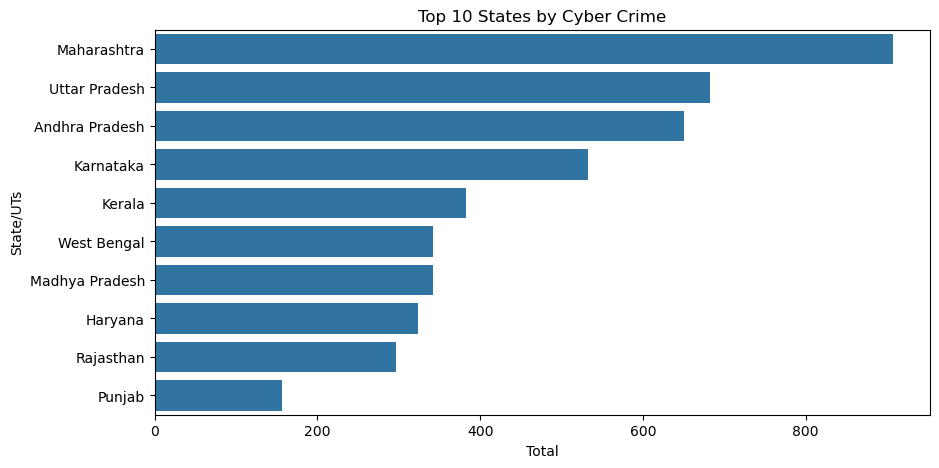

In [40]:
# Top 10 states
top_states = df_clean.sort_values(by="Total", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x="Total", y="State/UTs", data=top_states)
plt.title("Top 10 States by Cyber Crime")
plt.show()



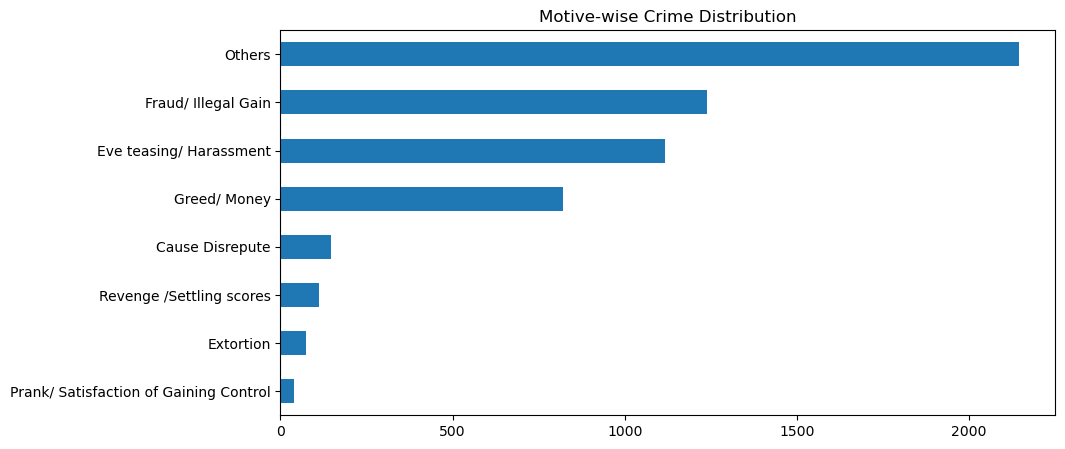

In [41]:
# Motives
motives = df_clean.drop(columns=["State/UTs", "Total"]).sum()
plt.figure(figsize=(10,5))
motives.sort_values().plot(kind='barh')
plt.title("Motive-wise Crime Distribution")
plt.show()

In [42]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

if 'Total' in numeric_cols:
    numeric_cols.remove('Total')

X = df_clean[numeric_cols]
y = df_clean['Total']

print("Features:", numeric_cols)

Features: ['Revenge /Settling scores', 'Greed/ Money', 'Extortion', 'Cause Disrepute', 'Prank/ Satisfaction of Gaining Control', 'Fraud/ Illegal Gain', 'Eve teasing/ Harassment', 'Others']


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [46]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y, pred))
    print("MSE:", mean_squared_error(y, pred))
    print("R2 :", r2_score(y, pred))
    return pred

lr_pred = evaluate("Linear Regression", lr, X_test_scaled, y_test)
rf_pred = evaluate("Random Forest", rf, X_test, y_test)


Linear Regression
MAE: 5.842240271805268e-14
MSE: 4.779445271099037e-27
R2 : 1.0

Random Forest
MAE: 24.230000000000004
MSE: 945.310288888889
R2 : 0.9580145912886323


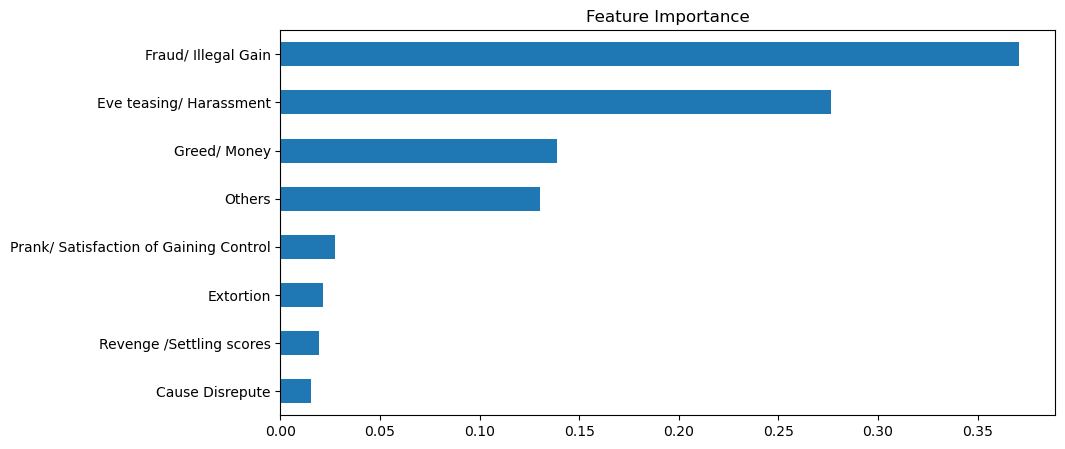

In [47]:
importances = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

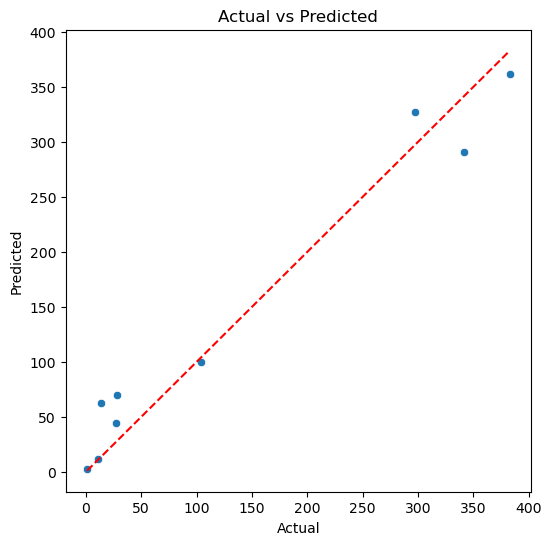

In [48]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

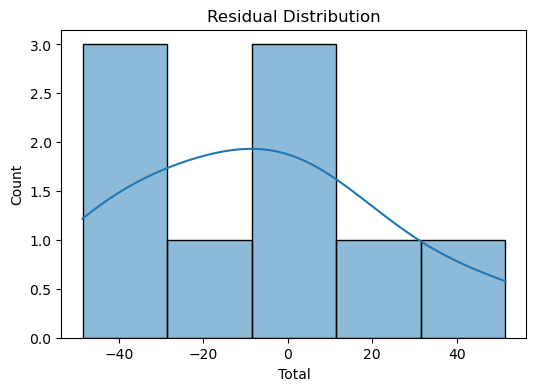

In [49]:
residuals = y_test - rf_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

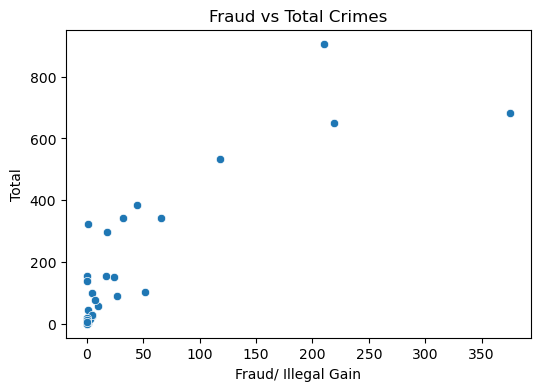

In [50]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_clean["Fraud/ Illegal Gain"], y=df_clean["Total"])
plt.title("Fraud vs Total Crimes")
plt.show()

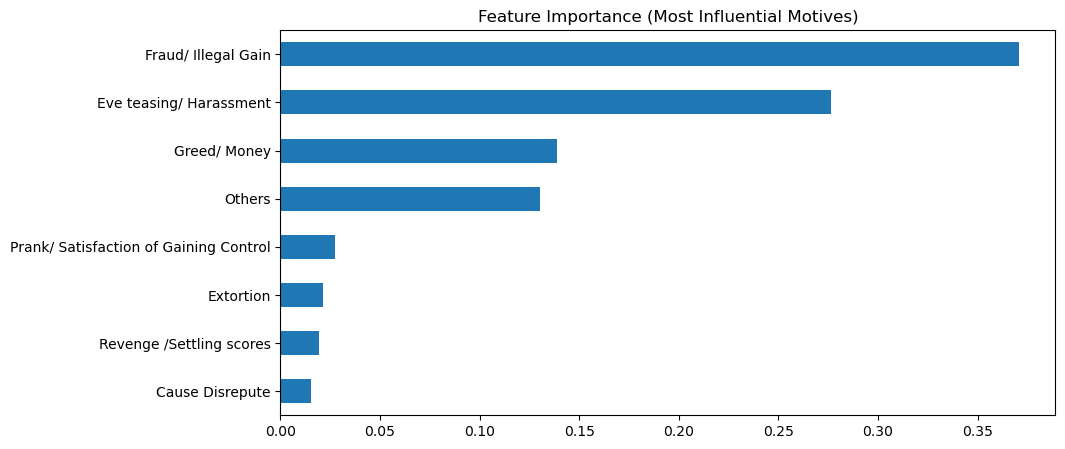

In [51]:
importances = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,5))
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance (Most Influential Motives)")
plt.show()

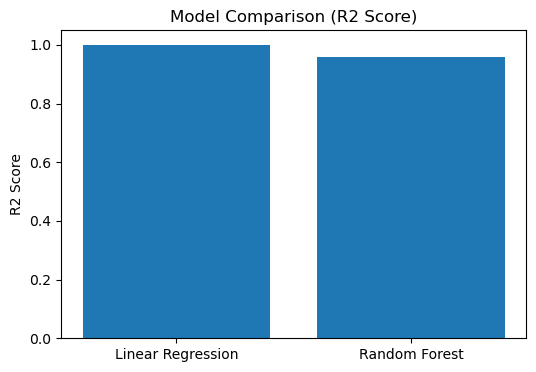

In [52]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred)
]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

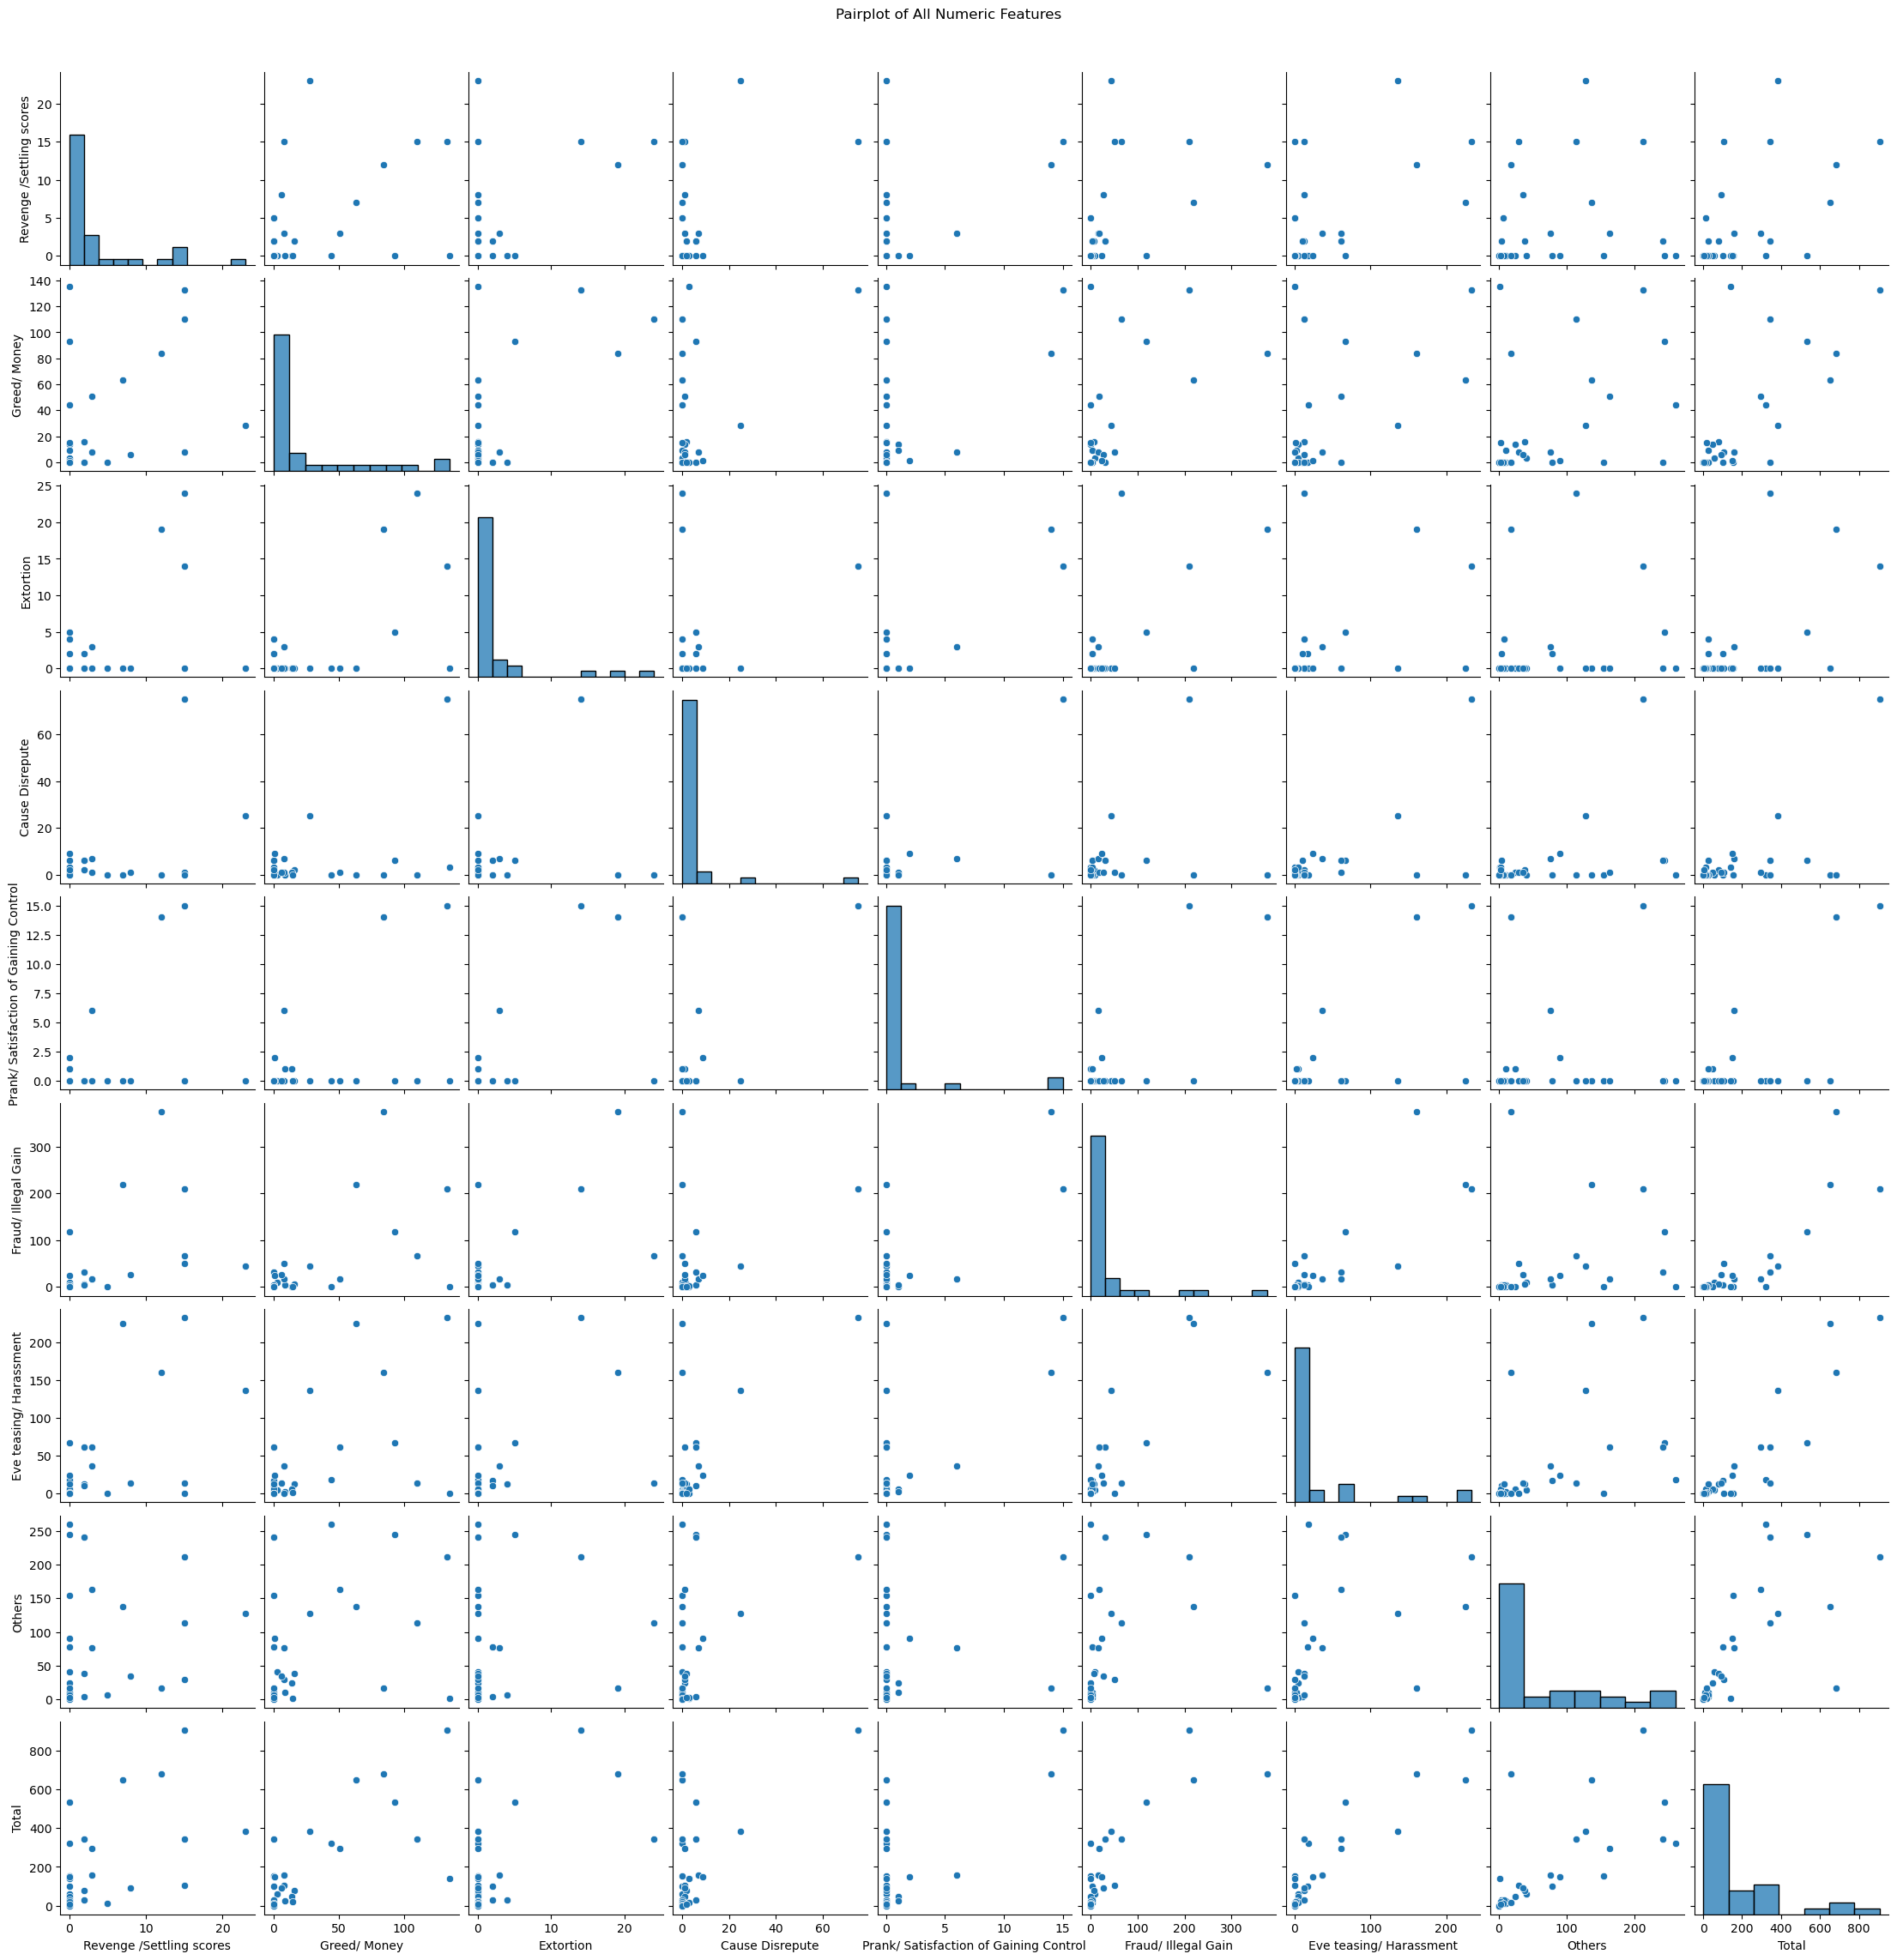

In [53]:
sns.pairplot(df_clean.select_dtypes(include=np.number))
plt.suptitle("Pairplot of All Numeric Features", y=1.02)
plt.show()

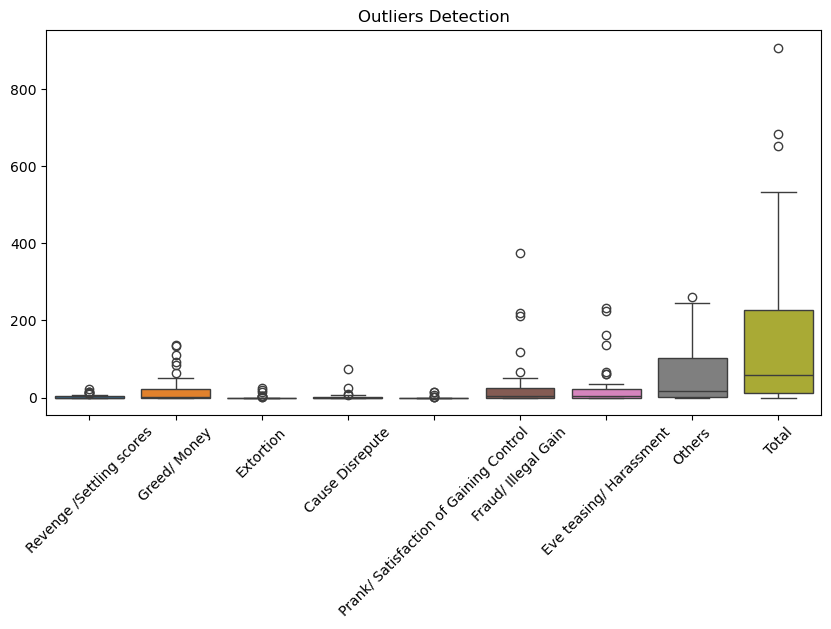

In [54]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

In [55]:
top_state = df_clean.loc[df_clean['Total'].idxmax(), 'State/UTs']
print("State with highest cyber crime:", top_state)

State with highest cyber crime: Maharashtra


In [56]:
top_motive = df_clean.drop(columns=["State/UTs", "Total"]).sum().idxmax()
print("Most common cyber crime motive:", top_motive)

Most common cyber crime motive: Others


In [57]:
def predict_crime(input_data):
    input_df = pd.DataFrame([input_data])
    prediction = rf.predict(input_df)
    return prediction

# Example
sample = X.iloc[0].to_dict()
print("Predicted Total Crimes:", predict_crime(sample))

Predicted Total Crimes: [619.725]


In [58]:
print(df_clean.sort_values(by="Total", ascending=False).head(5))


         State/UTs  Revenge /Settling scores  Greed/ Money  Extortion  \
14     Maharashtra                        15           133         14   
25   Uttar Pradesh                        12            84         19   
0   Andhra Pradesh                         7            63          0   
11       Karnataka                         0            93          5   
12          Kerala                        23            28          0   

    Cause Disrepute  Prank/ Satisfaction of Gaining Control  \
14               75                                      15   
25                0                                      14   
0                 0                                       0   
11                6                                       0   
12               25                                       0   

    Fraud/ Illegal Gain  Eve teasing/ Harassment  Others  Total  
14                  210                      233     212    907  
25                  375                      161  

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



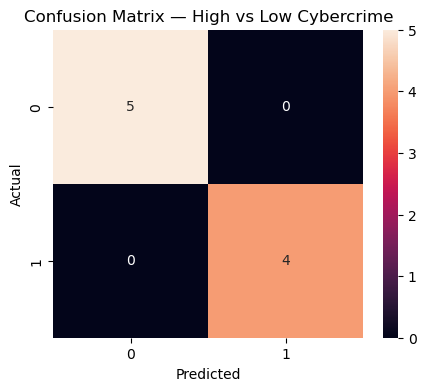

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

y_class = (df_clean["Total"] > df_clean["Total"].median()).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.25, random_state=42
)

clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)
pred_c = clf.predict(X_test_c)

print(classification_report(y_test_c, pred_c))

cm = confusion_matrix(y_test_c, pred_c)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix — High vs Low Cybercrime")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()